In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error,accuracy_score,classification_report,confusion_matrix

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.drop(columns=["customerID"],inplace=True,errors="ignore")

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
df.select_dtypes(include="float").columns.tolist()

['MonthlyCharges', 'TotalCharges']

In [8]:
df.isnull().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

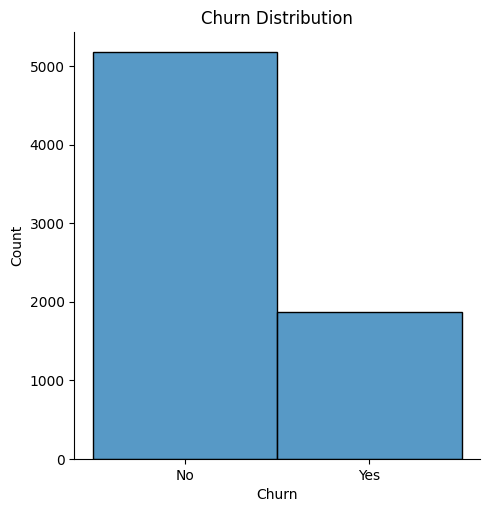

In [9]:
sns.displot(data=df,x="Churn")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

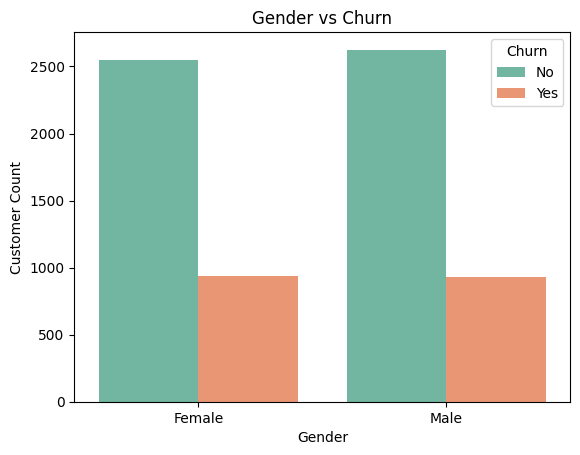

In [10]:
# gender vs churn
sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Set2"
)
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

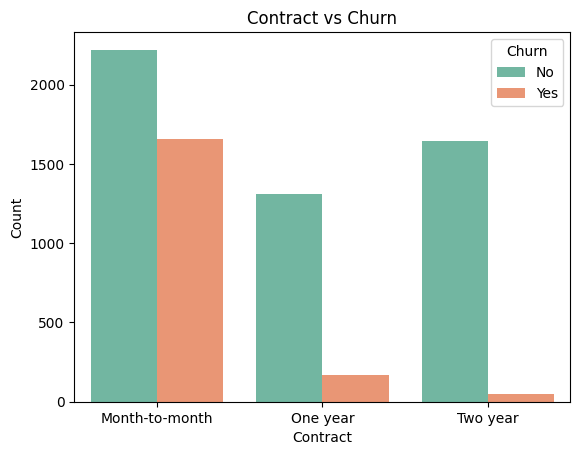

In [11]:
# Contract Type vs Churn
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2"
)
plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6340\187642930.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


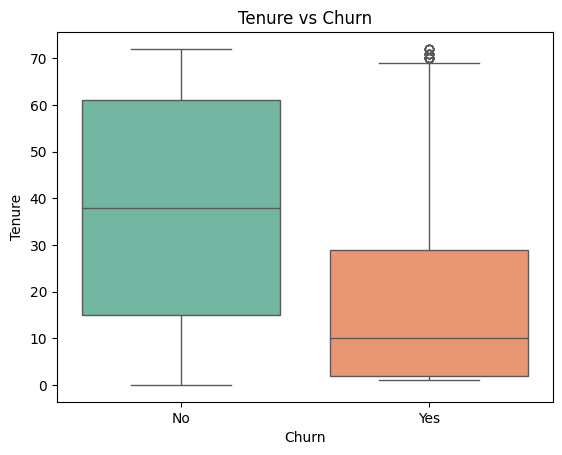

In [12]:
# Tenure vs Churn
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="Set2"
)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

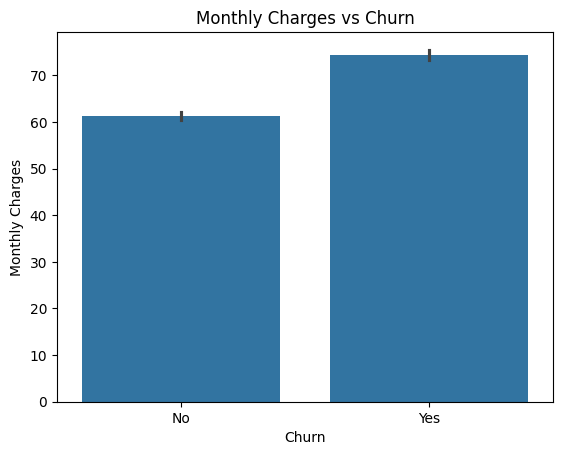

In [13]:
sns.barplot(
    data=df,
    y="MonthlyCharges",
    x="Churn"
)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

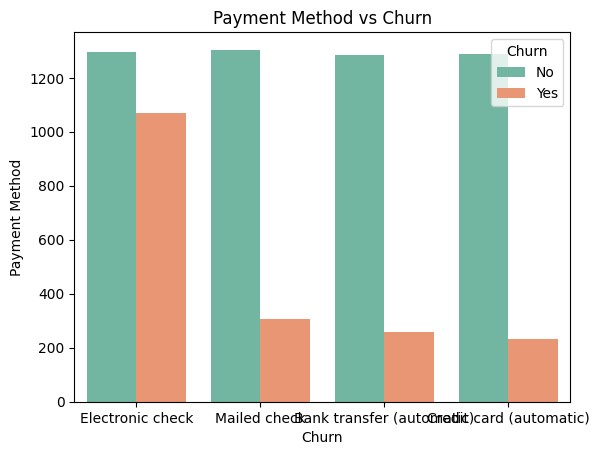

In [14]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set2"
)
plt.title("Payment Method vs Churn")
plt.xlabel("Churn")
plt.ylabel("Payment Method")
plt.show()

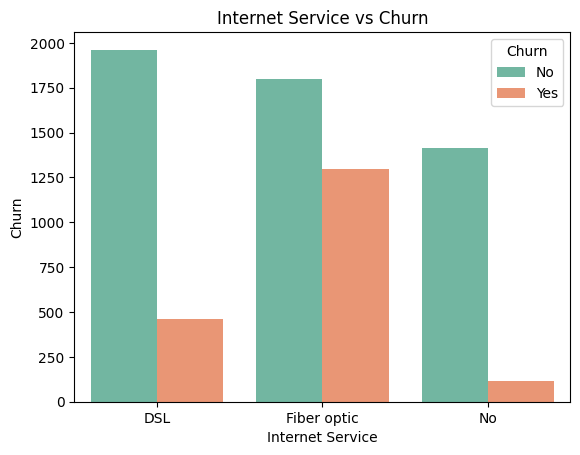

In [15]:
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set2"
)
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Churn")
plt.show()

In [16]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

le = LabelEncoder()
y = le.fit_transform(y)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int","float"]).columns.tolist()

num_pipe = Pipeline([("scaler",StandardScaler())])
cat_pipe = Pipeline([("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False,drop="first"))])

preprocessor = ColumnTransformer(transformers=[("num",num_pipe,num_cols),("cat",cat_pipe,cat_cols)],verbose_feature_names_out=False)

In [17]:
X_remaining, X_unseen, y_remaining, y_unseen = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.2,
    random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
X_unseen = preprocessor.transform(X_unseen)

In [18]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train,y_train)
lrp = lr.predict(X_test)
lrpu = lr.predict(X_unseen)
print("Accuracy : ",accuracy_score(y_test,lrp))
print("Unseen Accuracy : ",accuracy_score(y_unseen,lrpu))
print("Unseen Confuision Matrix : \n",confusion_matrix(y_unseen,lrpu))
print("Unseen Classification Report : \n",classification_report(y_unseen,lrpu))

Accuracy :  0.7988958990536278
Unseen Accuracy :  0.8170212765957446
Unseen Confuision Matrix : 
 [[461  50]
 [ 79 115]]
Unseen Classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.90      0.88       511
           1       0.70      0.59      0.64       194

    accuracy                           0.82       705
   macro avg       0.78      0.75      0.76       705
weighted avg       0.81      0.82      0.81       705



In [19]:
dt = DecisionTreeClassifier(min_samples_leaf=5,min_samples_split=100,random_state=34)
dt.fit(X_train,y_train)
dtp = dt.predict(X_test)
dtpu = dt.predict(X_unseen)
print("Accuracy : ",accuracy_score(y_test,dtp))
print("Accuracy : ",accuracy_score(y_unseen,dtpu))
print("Confuision Matrix : \n",confusion_matrix(y_unseen,dtpu))
print("Classification Report : \n",classification_report(y_unseen,dtpu))

Accuracy :  0.7910094637223974
Accuracy :  0.7843971631205674
Confuision Matrix : 
 [[463  48]
 [104  90]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       511
           1       0.65      0.46      0.54       194

    accuracy                           0.78       705
   macro avg       0.73      0.68      0.70       705
weighted avg       0.77      0.78      0.77       705



In [20]:
rf = RandomForestClassifier(n_estimators=100,min_samples_split=100,min_samples_leaf=5,random_state=45)
rf.fit(X_train,y_train)
rfp = rf.predict(X_test)
rfpu = rf.predict(X_unseen)
print("Accuracy : ",accuracy_score(y_test,rfp))
print("Unseen Accuracy : ",accuracy_score(y_unseen,rfpu))

print("Confuision Matrix : \n",confusion_matrix(y_unseen,rfpu))
print("Classification Report : \n",classification_report(y_unseen,rfpu))

Accuracy :  0.8012618296529969
Unseen Accuracy :  0.8
Confuision Matrix : 
 [[474  37]
 [104  90]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.82      0.93      0.87       511
           1       0.71      0.46      0.56       194

    accuracy                           0.80       705
   macro avg       0.76      0.70      0.72       705
weighted avg       0.79      0.80      0.79       705



In [21]:
adb = AdaBoostClassifier(estimator=dt,n_estimators=50,learning_rate=0.01, random_state=42)
adb.fit(X_train,y_train)
adbp = adb.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,adbp))
print("Confuision Matrix : \n",confusion_matrix(y_test,adbp))
print("Classification Report : \n",classification_report(y_test,adbp))

Accuracy :  0.8004731861198738
Confuision Matrix : 
 [[847  87]
 [166 168]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.91      0.87       934
           1       0.66      0.50      0.57       334

    accuracy                           0.80      1268
   macro avg       0.75      0.70      0.72      1268
weighted avg       0.79      0.80      0.79      1268



In [22]:
gb = GradientBoostingClassifier(n_estimators=1000,learning_rate=0.01,max_depth=5,max_leaf_nodes=10,random_state=56)
gb.fit(X_train,y_train)
gbp = gb.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,gbp))
print("Confuision Matrix : \n",confusion_matrix(y_test,gbp))
print("Classification Report : \n",classification_report(y_test,gbp))

Accuracy :  0.7996845425867508
Confuision Matrix : 
 [[838  96]
 [158 176]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.90      0.87       934
           1       0.65      0.53      0.58       334

    accuracy                           0.80      1268
   macro avg       0.74      0.71      0.72      1268
weighted avg       0.79      0.80      0.79      1268



In [23]:
xg = XGBClassifier(objective="multi:softmax",
    num_class=2,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)
xg.fit(X_train,y_train)
xgp = xg.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,xgp))
print("Confuision Matrix : \n",confusion_matrix(y_test,xgp))
print("Classification Report : \n",classification_report(y_test,xgp))

Accuracy :  0.8036277602523659
Confuision Matrix : 
 [[847  87]
 [162 172]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.91      0.87       934
           1       0.66      0.51      0.58       334

    accuracy                           0.80      1268
   macro avg       0.75      0.71      0.73      1268
weighted avg       0.79      0.80      0.79      1268



In [24]:
lgb = LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31,random_state=42,verbose=-1)

lgb.fit(X_train,y_train)
lgp = lgb.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,lgp))
print("Confuision Matrix : \n",confusion_matrix(y_test,lgp))
print("Classification Report : \n",classification_report(y_test,lgp))

Accuracy :  0.7957413249211357
Confuision Matrix : 
 [[838  96]
 [163 171]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.90      0.87       934
           1       0.64      0.51      0.57       334

    accuracy                           0.80      1268
   macro avg       0.74      0.70      0.72      1268
weighted avg       0.79      0.80      0.79      1268



In [25]:
cb = CatBoostClassifier(n_estimators=100,max_depth=10,learning_rate=0.1,random_state=45,verbose=0)
cb.fit(X_train,y_train)
cbp = cb.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,cbp))
print("Confuision Matrix : \n",confusion_matrix(y_test,cbp))
print("Classification Report : \n",classification_report(y_test,cbp))

Accuracy :  0.7949526813880127
Confuision Matrix : 
 [[833 101]
 [159 175]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.89      0.87       934
           1       0.63      0.52      0.57       334

    accuracy                           0.79      1268
   macro avg       0.74      0.71      0.72      1268
weighted avg       0.79      0.79      0.79      1268



In [ ]:
importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": xg.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance.head(10)

In [35]:
import pickle
with open("churn_model.pkl","wb") as file:
    pickle.dump(lr,file)
with open("preprocessor.pkl","wb") as file:
    pickle.dump(preprocessor,file)